In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import os

load_dotenv()

True

In [3]:
generator_llm = ChatGroq(model='llama-3.1-8b-instant', api_key=os.getenv("GROQ_API_KEY"))
evaluator_llm = ChatGroq(model='llama-3.1-8b-instant', api_key=os.getenv("GROQ_API_KEY"))
optimizer_llm = ChatGroq(model='llama-3.1-8b-instant', api_key=os.getenv("GROQ_API_KEY"))

In [5]:
class PostState(TypedDict):
  topic: str
  post: str
  evaluation: Literal['approved', 'need-improvement']
  feedback: str
  iteration: int 
  max_iterations: int


In [17]:
def generate_post(state: PostState) -> PostState:
  prompt = f"Write a social media post about the following topic: '{state['topic']}'. Make it funny and engaging. Iteration {state['iteration']} of {state['max_iterations']}."
  post = generator_llm.invoke(prompt)
  return {'post': post.content.strip()}

def evaluate_post(state: PostState) -> PostState:
  prompt = f"Evaluate the following social media post on the topic '{state['topic']}': '{state['post']}'. Respond with 'approved' if the post is good, or 'need-improvement' if it needs work. Also provide feedback for improvement."
  evaluation = evaluator_llm.invoke(prompt)
  eval_content = evaluation.content.strip().lower()
  if 'approved' in eval_content:
    eval_result = 'approved'
  else:
    eval_result = 'need-improvement'
  feedback = evaluation.content.strip()
  return {'evaluation': eval_result, 'feedback': feedback}

def optimize_post(state: PostState) -> PostState:
  prompt = f"Optimize the following social media post based on the feedback provided. Topic: '{state['topic']}', Post: '{state['post']}', Feedback: '{state['feedback']}'."
  optimized_post = optimizer_llm.invoke(prompt)
  return {'post': optimized_post.content.strip()}

def route_evaluation(state: PostState) -> str:
  return state['evaluation']

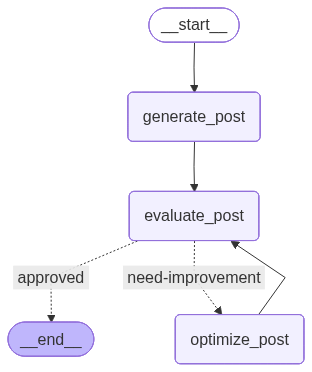

In [20]:
graph = StateGraph(PostState)

graph.add_node('generate_post', generate_post)
graph.add_node('evaluate_post', evaluate_post)
graph.add_node('optimize_post', optimize_post)

graph.add_edge(START, 'generate_post')
graph.add_edge('generate_post', 'evaluate_post')
graph.add_conditional_edges('evaluate_post',route_evaluation,{'approved': END, 'need-improvement': 'optimize_post'}
)
graph.add_edge('optimize_post', 'evaluate_post')

workflow = graph.compile()
workflow

In [19]:
initial_state = {
  'topic': 'the benefits of using AI in daily life',
  'iteration': 1,
  'max_iterations': 3
}
workflow.invoke(initial_state)

{'topic': 'the benefits of using AI in daily life',
 'post': '"BREAKING: AI is no longer just for robots and sci-fi movies! \n\nWe\'ve got the scoop on the real benefits of using AI in your daily life, and let\'s just say it\'s a GAME CHANGER. \n\nNo more tedious tasks, no more endless hours of scrolling through memes (although, let\'s be real, that\'s a tough one to give up). \n\nWith AI, you can:\n\n Automate your to-do list (bye, boring tasks!)\n Get personalized recommendations for your favorite shows and movies (hello, Netflix genius!)\n Even use virtual assistants to order pizza (because, priorities)\n\nSo, what are you waiting for? Join the AI revolution and upgrade your daily life to the next level! #AIforLife #FutureIsNow"',
 'evaluation': 'approved',
 'feedback': 'Approved\n\nThe post effectively grabs the reader\'s attention with a catchy title and a sense of urgency. The use of emojis and colloquial expressions like \'GAME CHANGER\' and \'hello, Netflix genius!\' adds a lig